# Escape Time around a Hyperbolic Fixed Point

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.integrator.integrate import FastSitnikovSimulation
from src.utils.plotting import plot_position_sitnikov, polar_scatter

In [2]:
e = 0.5
sim = FastSitnikovSimulation(e = e)

With the phi_fast implementation, there is no numerical fixed point (v,2pi) = phi_fast(v,0). So I will accept some value of t=0 which is allowed to be lower.

In [56]:
# Two-stage optimization:
# 1) brentq seed at t=0 enforcing t_out = 2*pi
# 2) 2D refinement in (v, t) minimizing residuals
import scipy.optimize as optimize

t0 = 0.0
period = 2.0 * np.pi

def periodic_delta(x, ref, p=period):
    return ((float(x) - float(ref) + 0.5 * p) % p) - 0.5 * p

def phi_fast_safe(v, t, t_max=200.0):
    v_out, t_out = sim.phi_fast(v=float(v), t=float(t), t_max=t_max, return_mod_period=False)
    return v_out, t_out

# ---------- Stage 1: 1D brentq at t=0 ----------
def time_to_2pi_error(v):
    _, t_out = phi_fast_safe(v=v, t=t0, t_max=200.0)
    if t_out is None:
        return np.nan
    return float(t_out) - period

a, b = 0.5, 2.6

v_seed = optimize.brentq(time_to_2pi_error, a, b, xtol=1e-14, rtol=1e-14, maxiter=1000)

# ---------- Stage 2: 2D least-squares refinement in (v, t) ----------
def residual_vector_vt(x):
    v = float(x[0])
    t = float(x[1])
    v_out, t_out = phi_fast_safe(v=v, t=t, t_max=200.0)

    if v_out is None or t_out is None:
        return np.array([1e3, 1e3], dtype=float)

    dv = float(v_out) - v
    dt = periodic_delta(t_out, t)
    return np.array([dv, dt], dtype=float)

refined = optimize.least_squares(
    residual_vector_vt,
    x0=np.array([float(v_seed), float(t0)], dtype=float),
    bounds=(np.array([0.5, -0.5]), np.array([2.6, 0.5])),
    xtol=1e-14,
    ftol=1e-14,
    gtol=1e-14,
    max_nfev=15000,
)

v_hyper = float(refined.x[0])
t_hyper = float(refined.x[1])
r_final = residual_vector_vt([v_hyper, t_hyper])

print(f"Stage-1 seed (brentq at t=0): v_seed = {v_seed:.16f}")
print(f"Refined solution: v_hyper = {v_hyper:.16f}, t_hyper = {t_hyper:.16e}")
print(f"Residuals: dv = {r_final[0]:.3e}, dt = {r_final[1]:.3e}")
print(f"L2 norm = {np.linalg.norm(r_final):.3e}")

Stage-1 seed (brentq at t=0): v_seed = 2.5491243115378572
Refined solution: v_hyper = 2.5491241932335584, t_hyper = 1.8820435653354643e-07
Residuals: dv = -9.326e-15, dt = -1.243e-14
L2 norm = 1.554e-14


## We compute the unstable manifold

In [63]:
def wrap_time_to_center(t_values, center, period=2.0 * np.pi):
    t_arr = np.asarray(t_values, dtype=float)
    return center + np.mod(t_arr - center + 0.5 * period, period) - 0.5 * period


def iterate_phi_n(sim, v0, t0, n_iter=3, t_step_max=100.0):
    t_curr = float(t0)
    v_curr = float(v0)

    for _ in range(n_iter):
        v_curr, t_curr = sim.phi_fast(v=v_curr, t=t_curr, t_max=t_step_max, return_mod_period=True)
        if v_curr is None or t_curr is None:
            return None, None

    return t_curr, v_curr

eps = 1e-12
k = 100
n_iter = 6
x_neg = np.linspace(-k*eps, -eps, 50)
x_pos = np.linspace(eps, k*eps, 50)
x_vals = np.concatenate((x_neg, x_pos))

manifold_t = []
manifold_v = []

for x in x_vals:
    t_end, v_end = iterate_phi_n(sim, v_hyper, t_hyper + x, n_iter=n_iter, t_step_max=100.0)
    if t_end is not None and v_end is not None:
        manifold_t.append(float(t_end))
        manifold_v.append(float(v_end))

manifold_t = np.asarray(manifold_t, dtype=float)
manifold_v = np.asarray(manifold_v, dtype=float)

manifold_t = wrap_time_to_center(manifold_t, center=float(t_hyper))


print(f"Computed unstable-manifold points: {manifold_t.size}")

Computed unstable-manifold points: 100


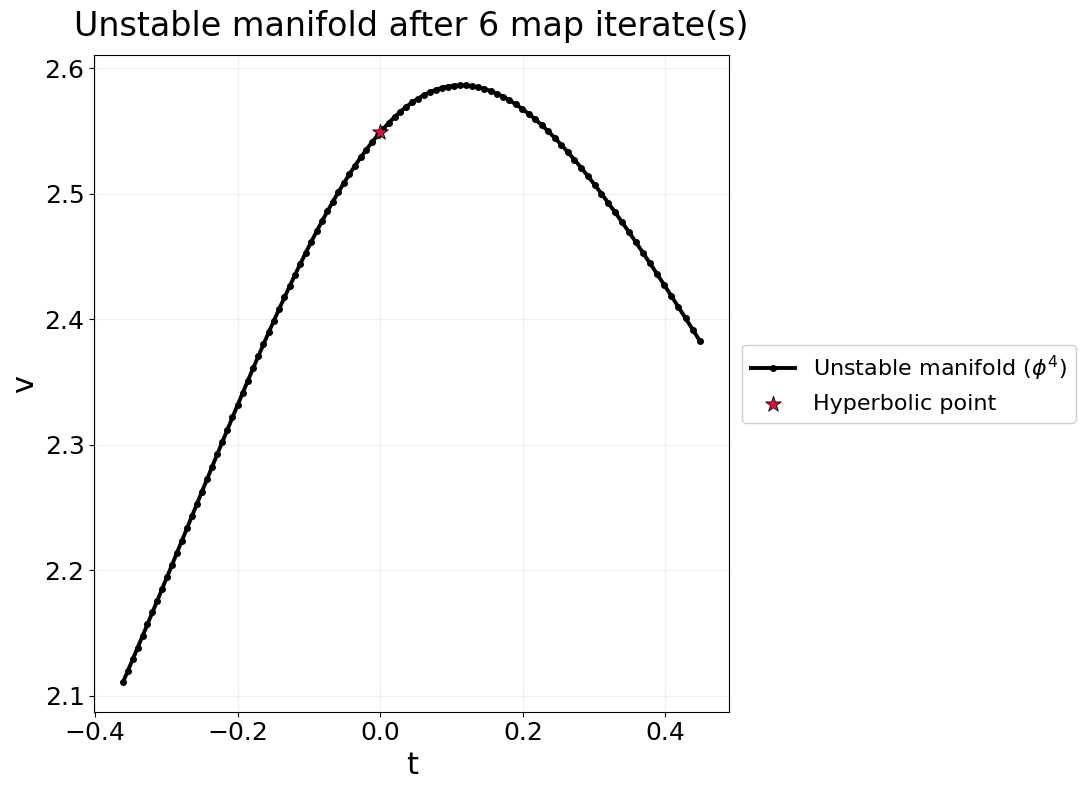

In [64]:
fig, ax = plt.subplots(figsize=(11, 8))

if manifold_t.size > 1:
    ax.plot(
        manifold_t,
        manifold_v,
        color="black",
        linewidth=2.8,
        marker="o",
        markersize=4,
        label=r"Unstable manifold ($\phi^4$)",
    )

ax.scatter(
    [t_hyper],
    [v_hyper],
    s=140,
    c="crimson",
    marker="*",
    edgecolors="k",
    linewidths=0.6,
    zorder=8,
    label="Hyperbolic point",
)

ax.set_title(f"Unstable manifold after {n_iter} map iterate(s)", fontsize=24, pad=14)
ax.set_xlabel("t", fontsize=22)
ax.set_ylabel("v", fontsize=22)
ax.tick_params(axis="both", labelsize=18)
ax.grid(alpha=0.2)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    framealpha=0.95,
    fontsize=16,
    borderaxespad=0.0,
)

fig.tight_layout()
plt.show()

## We compute crossings in a grid around the hyperbolic fixed point

In [59]:
N = 33

t_vals = np.linspace(t_hyper - 0.2, t_hyper + 0.2, N)
v_vals = np.linspace(v_hyper - 0.1, v_hyper + 0.1, N)

T, V = np.meshgrid(t_vals, v_vals)
t_grid = T.ravel()
v_grid = V.ravel()

crossings_fn = getattr(sim, "fast_crossings_iterated", None)
if crossings_fn is None:
    crossings_fn = sim.fast_crossings_iterated

escape_crossings = np.array([
    crossings_fn(v=v0, t=t0)
    for t0, v0 in zip(t_grid, v_grid)
], dtype=float)

print(f"Computed {escape_crossings.size} grid points ({N}x{N}).")

Computed 1089 grid points (33x33).


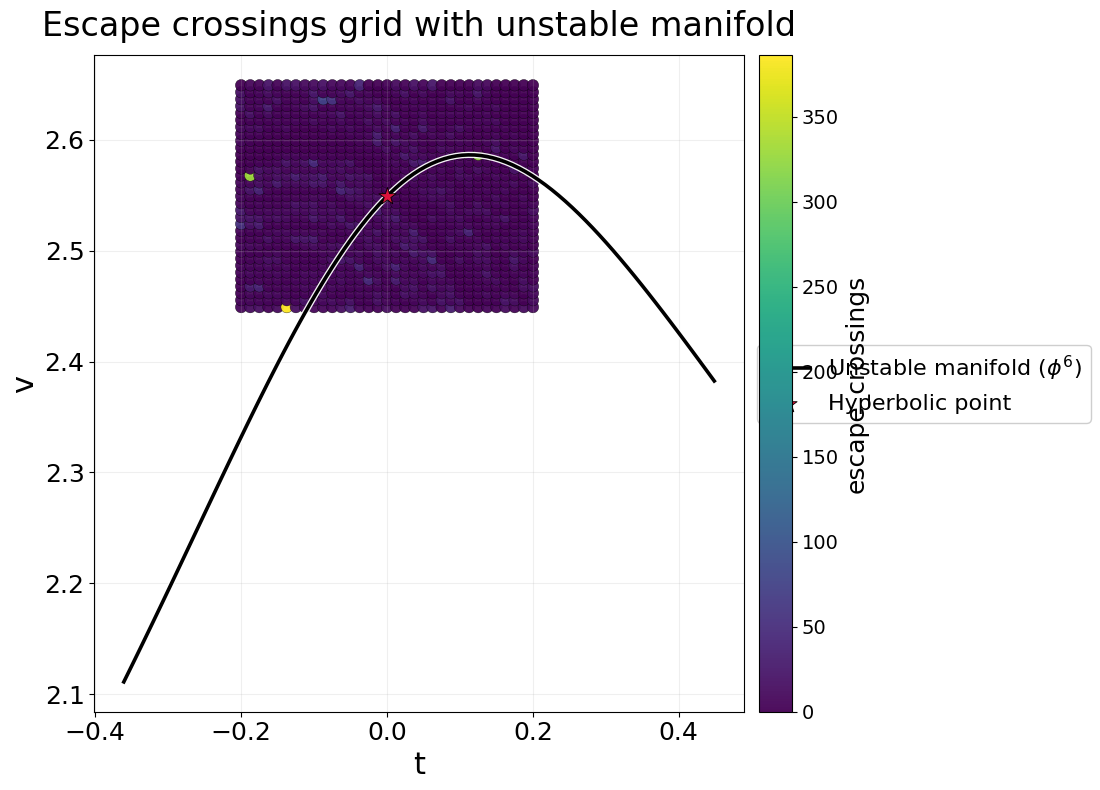

In [ ]:
fig, ax = plt.subplots(figsize=(11, 8))

# Grid domain limits (exactly the NxN sampling window)
t_min, t_max = float(np.min(t_vals)), float(np.max(t_vals))
v_min, v_max = float(np.min(v_vals)), float(np.max(v_vals))

# Color-coded crossings on the (t, v) grid
sc = ax.scatter(
    t_grid,
    v_grid,
    c=escape_crossings,
    s=70,
    cmap="viridis",
    edgecolors="k",
    linewidths=0.25,
    alpha=0.95,
)

# Keep only manifold points inside the same plotting window
if manifold_t.size > 1:
    inside = (
        (manifold_t >= t_min)
        & (manifold_t <= t_max)
        & (manifold_v >= v_min)
        & (manifold_v <= v_max)
    )

    if np.any(inside):
        t_inside = manifold_t[inside]
        v_inside = manifold_v[inside]
        order = np.argsort(t_inside)

        ax.plot(
            t_inside[order],
            v_inside[order],
            color="white",
            linewidth=4.5,
            alpha=0.95,
            zorder=6,
        )
        ax.plot(
            t_inside[order],
            v_inside[order],
            color="black",
            linewidth=2.6,
            label=rf"Unstable manifold ($\phi^{{{n_iter}}}$)",
            zorder=7,
        )

# Plot hyperbolic point only if it is inside the same window
if (t_min <= t_hyper <= t_max) and (v_min <= v_hyper <= v_max):
    ax.scatter(
        [t_hyper],
        [v_hyper],
        s=170,
        c="crimson",
        marker="*",
        edgecolors="k",
        linewidths=0.6,
        zorder=8,
        label="Hyperbolic point",
    )

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("escape_crossings", fontsize=18)
cbar.ax.tick_params(labelsize=14)

ax.set_title("Escape crossings grid with unstable manifold", fontsize=24, pad=14)
ax.set_xlabel("t", fontsize=22)
ax.set_ylabel("v", fontsize=22)
ax.tick_params(axis="both", labelsize=18)
ax.grid(alpha=0.2)

# Force axes to match exactly the NxN grid rectangle
ax.set_xlim(t_min, t_max)
ax.set_ylim(v_min, v_max)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    framealpha=0.95,
    fontsize=16,
    borderaxespad=0.0,
)

fig.tight_layout()
plt.show()

In [19]:
from src.utils.plotting import save_figure
save_figure(
    fig,
    f"escape_time_around_hyperbolic_point_e={e:.1f}_v={v_hyper:.2f}_t={t_hyper:.2f}.png",
    folder_path="experiments/local_escape_time/figures",
)

WindowsPath('experiments/local_escape_time/figures/escape_time_around_hyperbolic_point_e=0.5_v=2.55_t=0.00.png.png')